# Análisis Exploratorio de Datos — Presas de Sinaloa

Proyecto: **SinAgua – Dashboard de Monitoreo de Presas de Sinaloa**
Archivo fuente: `src/data/data.json`

## Objetivo

Hacer un análisis exploratorio (EDA) sobre el dataset que alimenta al dashboard web con el fin de
**identificar mejoras aplicables a los datos para su visualización en la página**. El punto de vista
no es estadístico puro, sino orientado al *consumo del front‑end* (Chart.js, Leaflet): calidad,
consistencia, cobertura temporal, formato y estructura.

## Preguntas que buscamos responder

1. ¿El esquema actual (diccionario `fecha -> lista[registros]`) es adecuado para consulta en el navegador?
2. ¿Los tipos de dato son apropiados? (los valores llegan como *strings*)
3. ¿Hay nombres de presas inconsistentes, duplicados o con ortografía variable?
4. ¿Hay valores faltantes, marcadores no numéricos (`"-"`) o rangos atípicos (% > 100)?
5. ¿La cobertura temporal es homogénea entre presas? ¿Qué tan grande es la brecha entre fechas publicadas?
6. ¿Qué información es dinámica (nivel, % , almacenamiento) vs. estática (capacidades, elevaciones)?
   ¿Conviene separarla en metadatos para reducir el peso del archivo?

---

## 0. Contexto del pipeline de datos

```
data/<año>/*.pdf          ->  scripts/descargar_pdf.js       (fuente CIDH Sinaloa)
json/<año>/datos-*.json   ->  scripts/convertir_a_json_YYYY.js
json/  (todos los años)   ->  scripts/aggregate_data.js      -> src/data/data.json
src/data/data.json        ->  index.html (fetch) + src/js/script.js  -> gráficas y mapa
```

`data.json` es un `dict` ordenado: la **clave es la fecha** (`"YYYY-MM-DD"`) y el
**valor es un arreglo** de presas con estos campos:

| Campo                   | Tipo en JSON | Significado                          |
|-------------------------|--------------|--------------------------------------|
| `nombre`                | string       | Nombre de la presa                   |
| `capacidadConservacion` | string       | Capacidad total de conservación (Mm³)|
| `elevacionConservacion` | string       | Elevación NAIMO (m)                  |
| `capacidadNamo`         | string       | Capacidad NAMO (Mm³)                 |
| `elevacionNamo`         | string       | Elevación NAMO (m)                   |
| `almacenamientoActualMm3`| string      | Almacenamiento actual (Mm³)          |
| `porcentaje`            | string       | Nivel de llenado (%)                 |

> Observación preliminar: **todos los números son cadenas de texto**. Eso obliga a `parseFloat()`
> en cada render del front-end y dificulta comparaciones/agregaciones. Es un primer candidato de mejora.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.figsize': (11, 4.5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 140)

DATA_PATH = Path('../src/data/data.json')   # ejecutar desde eda/
assert DATA_PATH.exists(), f'No existe {DATA_PATH.resolve()}'

with open(DATA_PATH) as f:
    raw = json.load(f)

print(f'Fechas distintas      : {len(raw)}')
print(f'Rango                 : {min(raw)}  ->  {max(raw)}')
n_reg = sum(len(v) for v in raw.values())
print(f'Registros (presa-día) : {n_reg}')
print(f'Tamaño del archivo    : {DATA_PATH.stat().st_size/1e6:.1f} MB (JSON con indent 2)')


Fechas distintas      : 1709
Rango                 : 2019-01-03  ->  2026-09-11
Registros (presa-día) : 21250
Tamaño del archivo    : 5.7 MB (JSON con indent 2)


## 1. De estructura anidada a formato tabular (tidy data)

Transformamos el `dict` anidado en un `DataFrame` con una fila por *presa-día* y una columna
`fecha`. Este formato es el que mejor se presta a los análisis de calidad y cobertura.


In [2]:
rows = []
for fecha, registros in raw.items():
    for reg in registros:
        row = dict(reg)
        row['fecha'] = fecha
        rows.append(row)

df = pd.DataFrame(rows)
df['fecha'] = pd.to_datetime(df['fecha'])
df['anio'] = df['fecha'].dt.year

print(f'Shape: {df.shape}  ({(df.shape[1]-2)} variables + fecha/anio)')
print()
print('dtypes originales (todo object, es decir, texto):')
print(df.dtypes.drop(['fecha', 'anio']))
print()
df.head(3)


Shape: (21250, 9)  (7 variables + fecha/anio)

dtypes originales (todo object, es decir, texto):
nombre                     object
capacidadConservacion      object
elevacionConservacion      object
capacidadNamo              object
elevacionNamo              object
almacenamientoActualMm3    object
porcentaje                 object
dtype: object



,nombre,capacidadConservacion,elevacionConservacion,capacidadNamo,elevacionNamo,almacenamientoActualMm3,porcentaje,fecha,anio
0,Luis Donaldo Colosio,4568.0,290.00,3202.9,274.00,2373.1,74.1,2019-01-03,2019
1,Miguel Hidalgo y Costilla,4171.3,148.00,3312.9,142.36,2610.4,78.8,2019-01-03,2019
2,Josefa Ortiz de Domínguez,695.4,112.65,518.9,109.50,435.2,83.9,2019-01-03,2019


## 2. Calidad de tipos de dato: de texto a número

Convertimos las columnas numéricas a `float` contando cuántos valores **no son convertibles**.
Esos valores (`"-"`, espacios, comas) son los que hoy «rompen» o ensucian el front-end.


In [3]:
NUM_COLS = ['capacidadConservacion', 'elevacionConservacion', 'capacidadNamo',
            'elevacionNamo', 'almacenamientoActualMm3', 'porcentaje']

conversion = pd.DataFrame(index=NUM_COLS)
for col in NUM_COLS:
    serie = pd.to_numeric(df[col], errors='coerce')
    conversion.loc[col, 'convertibles'] = serie.notna().sum()
    conversion.loc[col, 'no_convertibles'] = serie.isna().sum()
    conversion.loc[col, 'pct_no_convertibles'] = (serie.isna().mean() * 100).round(2)

raros = {}
for col in NUM_COLS:
    vals = df[col]
    raros[col] = sorted({str(v) for v in vals if pd.isna(pd.to_numeric(pd.Series([v]), errors='coerce'))[0]})

conversion['valores_no_numericos_unicos'] = [raros[c] for c in NUM_COLS]
conversion


,convertibles,no_convertibles,pct_no_convertibles,valores_no_numericos_unicos
capacidadConservacion,21250.0,0.0,0.00,[]
elevacionConservacion,21250.0,0.0,0.00,[]
capacidadNamo,21250.0,0.0,0.00,[]
elevacionNamo,21250.0,0.0,0.00,[]
almacenamientoActualMm3,21248.0,2.0,0.01,[-]
porcentaje,21247.0,3.0,0.01,[-]


## 3. Duplicados y consistencia de identificadores

Un problema crítico para una visualización confiable: **el mismo objeto debe llamarse igual
siempre**. Aquí detectamos (a) duplicados exactos `(fecha, nombre)` y (b) nombres que se escriben
distinto pero referencian la misma presa (diferencias de acentos, abreviaturas, mayúsculas).


In [4]:
dups_exactos = df.duplicated(subset=['fecha', 'nombre']).sum()
print(f'Duplicados exactos (fecha, nombre): {dups_exactos}')

# Normalización: minúsculas, sin acentos, sin puntuación
import unicodedata, re
def norm(s):
    s = unicodedata.normalize('NFKD', s)
    s = ''.join(ch for ch in s if not unicodedata.combining(ch))
    return re.sub(r'[^a-z0-9]', '', s.lower())

# Dos variantes pueden diferir en token (abreviaturas: "Ortiz" -> "O.")
def tokens(s):
    s = unicodedata.normalize('NFKD', s)
    s = ''.join(ch for ch in s if not unicodedata.combining(ch))
    s = re.sub(r'[^a-z0-9 ]', ' ', s.lower())
    return {t for t in s.split()}

names = df['nombre'].unique()
tk = {n: tokens(n) for n in names}

# "es variante" si comparten la mayoría de tokens y la diferencia parece una abreviatura (token corto)
def es_variante(a, b):
    ta, tb = tk[a], tk[b]
    inter = ta & tb
    if not inter:
        return False
    extra = (ta - tb) | (tb - ta)
    if not extra or min(len(t) for t in extra) > 2:
        return False
    return len(inter) >= 0.5 * min(len(ta), len(tb))

# Agrupar por familias (unión-find) para detectar cadenas de variantes
parent = {n: n for n in names}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

for i, a in enumerate(names):
    for b in names[i + 1:]:
        if es_variante(a, b):
            parent[find(a)] = find(b)

from collections import defaultdict
familias = defaultdict(list)
for n in names:
    familias[find(n)].append(n)
familias = {k: v for k, v in familias.items() if len(v) > 1}

print('\nVariantes de nombre que se refieren a la misma presa:')
variantes = 0
for base, grupo in sorted(familias.items()):
    for v in sorted(grupo):
        n = df[df['nombre'] == v]['fecha'].min().date()
        x = df[df['nombre'] == v]['fecha'].max().date()
        cap = df[df['nombre'] == v]['capacidadConservacion'].iloc[0]
        print(f'   "{v}"  (capacidad {cap} Mm³)  [{n} -> {x}]')
        variantes += 1
if variantes == 0:
    print('   (ninguna detectada)')

print(f'\nTotal de nombres "crudos" en el dataset      : {len(names)}')
print(f'Total de presas únicas (familias)            : {len(names) - variantes}')


Duplicados exactos (fecha, nombre): 0

Variantes de nombre que se refieren a la misma presa:
   "Josefa O. de Dominguez"  (capacidad 695.4 Mm³)  [2021-01-04 -> 2023-04-12]
   "Josefa Ortiz de Domínguez"  (capacidad 695.4 Mm³)  [2019-01-03 -> 2026-09-11]

Total de nombres "crudos" en el dataset      : 19
Total de presas únicas (familias)            : 17


### Interpretación

La tabla anterior muestra la variante más relevante del dataset:

* **`Josefa Ortiz de Domínguez`** y **`Josefa O. de Dominguez`** son la **misma presa**
  (comparten capacidad `695.4` Mm³) pero el nombre cambió de un periodo a otro, y además
  **nunca coexisten en la misma fecha**. Para el gráfico de evolución esto significa que
  al seleccionar «Josefa…» la serie se parte en dos.

Sabemos además que los scripts de conversión producen variantes de acentos (p. ej.
`"Peña del Aguila"` sin tilde en «Águila») que hacen inconsistente la ordenación y búsqueda.

**Recomendación:** definir un diccionario canónico `{variante -> nombre_oficial}` (o normalizar con
`unicodedata`) en el paso de agregación, de modo que `data.json` siempre salga con nombres únicos.


## 4. Rangos atípicos y valores fuera de dominio

Dominios esperados (definidos por nuestra propia web):

* `porcentaje` ∈ [0, 100]  (el mapa usa `nivelColor(pct)`, y una leyenda con categorías).
* `almacenamientoActualMm3` ≥ 0 y ≤ `capacidadConservacion`.
* Coherencia interna: `porcentaje ≈ almacenamiento / capacidadNamo * 100`.

Revisamos las desviaciones a estos dominios.


In [5]:
pct = pd.to_numeric(df['porcentaje'], errors='coerce')
alm = pd.to_numeric(df['almacenamientoActualMm3'], errors='coerce')
namo = pd.to_numeric(df['capacidadNamo'], errors='coerce')

print('=== porcentaje fuera de [0, 100] ===')
out_pct = df[pct.gt(100) | pct.lt(0)]
print(f'  {len(out_pct)} registros ({len(out_pct)/len(df)*100:.2f}%)')
print(out_pct.groupby('nombre')['porcentaje'].agg(['count', 'min', 'max']).sort_values('count', ascending=False))

print('\n=== almacenamiento negativo ===')
neg = df[alm.lt(0)]
print(f'  {len(neg)} registros:', neg[['fecha', 'nombre', 'almacenamientoActualMm3']].head(5).to_dict('records'))

print('\n=== coherencia porcentaje vs almacenamiento/capacidadNAMO ===')
calc = alm / namo * 100
incoherente = df[calc.notna() & pct.notna() & (np.abs(calc - pct) > 0.51)]
print(f'  {len(incoherente)} registros donde el % no coincide con (alm/NAMO)*100 (±0.5 pp)')
print(incoherente.groupby('fecha')[['nombre']].agg(list).tail(8).head(8) if len(incoherente) else '  (ninguno)')


=== porcentaje fuera de [0, 100] ===
  494 registros (2.32%)
                         count    min    max
nombre                                      
Picachos                   271  100.1  325.7
Aurelio Benassini V.        94  100.1  110.8
Santiago Bayacora           32  100.1  103.7
Peña del Aguila             23  100.3  126.2
Guillermo Blake Aguilar     21  100.1  103.0
Sanalona                    20  100.1  102.0
Eustaquio Buelna            16  100.3  106.8
Caboraca                    12  100.2  103.8
Francisco Villa              3  100.1  100.4
Luis Donaldo Colosio         2  106.4  117.6

=== almacenamiento negativo ===
  4 registros: [{'fecha': Timestamp('2020-09-23 00:00:00'), 'nombre': 'Santiago Bayacora', 'almacenamientoActualMm3': '-0.2'}, {'fecha': Timestamp('2020-09-23 00:00:00'), 'nombre': 'Guadalupe Victoria', 'almacenamientoActualMm3': '-0.2'}, {'fecha': Timestamp('2020-09-23 00:00:00'), 'nombre': 'Francisco Villa', 'almacenamientoActualMm3': '-0.1'}, {'fecha': Timestam

### Interpretación

1. **`porcentaje` puede superar 100 %** (hasta ~107 % en Eustaquio Buelna). La fuente lo publica así;
   nuestra paleta (`nivelColor`) y las escalas `suggestedMax: 100` asumen [0, 100]. En el mapa un valor
   `>100` no tiene categoría.
2. El **22-sep/23-sep de 2020** hay registros con `porcentaje` y `almacenamiento` incoherentes entre sí
   (el % alto convive con un almacenamiento casi nulo). Una limpieza debería validar `% ≈ alm/NAMO*100`.


## 5. Cobertura y disponibilidad temporal

El dashboard agrega por año, por rango de días y por presa. La **cobertura irregular** afecta:

* el promedio estatal (con pocas presas el promedio se sesga),
* el chart comparativo por año (curvas incompletas),
* el mapa (presas sin dato en la última fecha).

### 5.1 Número de presas por día publicado


In [6]:
presas_x_fecha = df.groupby('fecha')['nombre'].nunique()
print(f'Fechas con cada nº de presas:')
print(presas_x_fecha.value_counts().rename_axis('n° presas').to_string())

# cuántas de esas fechas tienen TODAS las presas principales
print()
principales = ['Luis Donaldo Colosio', 'Miguel Hidalgo y Costilla', 'Gustavo Díaz Ordaz',
               'Guillermo Blake Aguilar', 'Eustaquio Buelna', 'Adolfo López Mateos',
               'Sanalona', 'Juan Guerrero Alcocer', 'José López Portillo', 'Aurelio Benassini V.']
completas = presas_x_fecha.ge(len(principales)).sum()
print(f'Días con al menos {len(principales)} presas reportadas: {completas}/{len(presas_x_fecha)} ({completas/len(presas_x_fecha)*100:.0f}%)')


Fechas con cada nº de presas:
n° presas
12    680
13    529
16    269
6     167
17     27
15     26
5       9
9       1
4       1

Días con al menos 10 presas reportadas: 1531/1709 (90%)


### 5.2 Heatmap de disponibilidad presa × mes-año

Filas = presas (ordenadas por primera aparición), columnas = `año-mes`. El color indica la
fracción de días del mes en que la presa aparece en los datos.


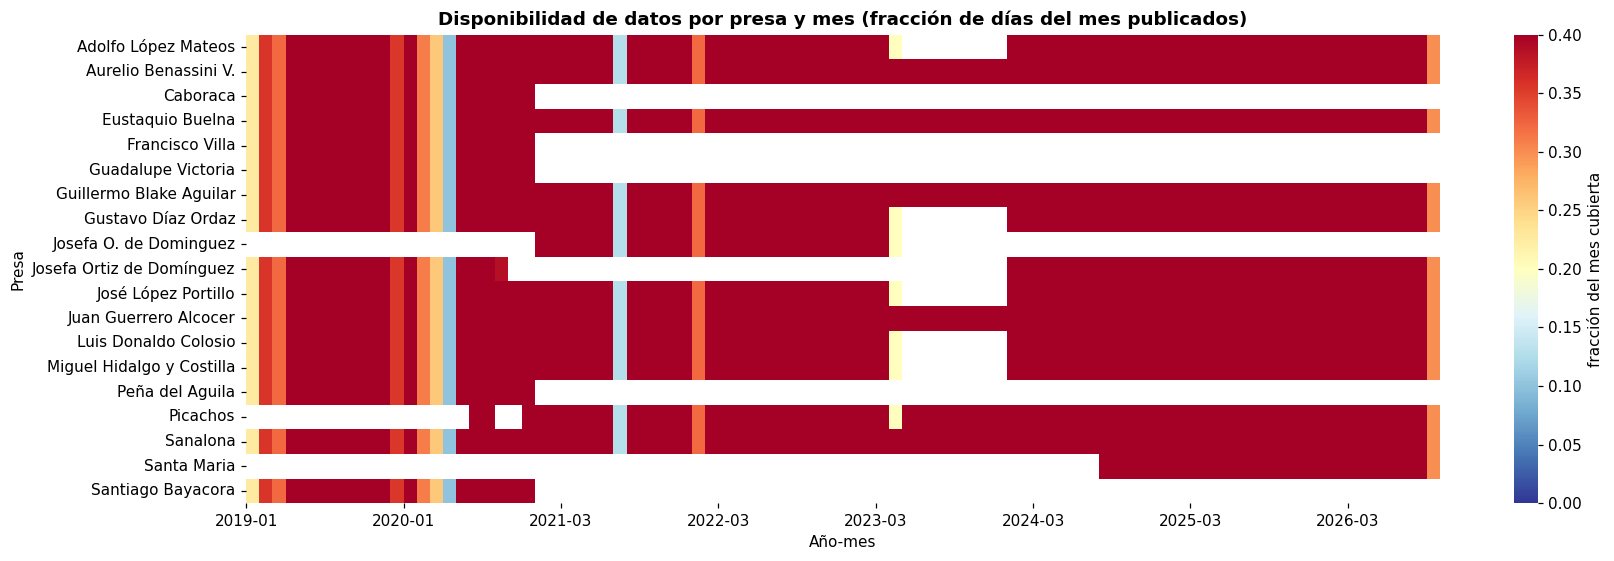

In [7]:
df['ym'] = df['fecha'].dt.to_period('M')
presence = df.pivot_table(index='nombre', columns='ym', values='fecha', aggfunc='count')

# fracción del mes cubierta: días con reporte / días del calendario
dias_en_mes = presence.columns.map(lambda p: p.days_in_month)
presence_frac = presence.div(dias_en_mes, axis=1).clip(upper=1)

fig, ax = plt.subplots(figsize=(16, 5.2))
sns.heatmap(presence_frac, ax=ax, cmap='RdYlBu_r', vmin=0, vmax=0.4, cbar_kws={'label': 'fracción del mes cubierta'})
ax.set_title('Disponibilidad de datos por presa y mes (fracción de días del mes publicados)')
ax.set_ylabel('Presa'); ax.set_xlabel('Año-mes')
xticks = list(range(0, len(presence_frac.columns), 12))
ax.set_xticks(xticks); ax.set_xticklabels([str(presence_frac.columns[i])[:7] for i in xticks], rotation=0)
plt.tight_layout(); plt.show()


### Interpretación de la cobertura

El heatmap muestra **tres generaciones de presas**:

| Grupo | Presas | Periodo | Efecto en la web |
|-------|--------|---------|------------------|
| Fundacionales | Colosio, Hidalgo, Blake, Buelna, Sanalona, Guerrero, Benassini (+ Josefina/Peña/G. Victoria/Santiago/Francisco Villa/Caboraca hasta 2020) | 2019 → hoy | serie larga |
| Presas de la sierra (montaña) | Santiago Bayacora, Guadalupe Victoria, Francisco Villa, Caboraca, Peña del Águila | solo hasta dic-2020 | desaparecen del gráfico «Histórico» al seleccionarlas |
| Nuevas incorporaciones | **Picachos** (ago-2020), **Santa Maria** (ago-2024), y el cambio de nombre de Josefina | 2020/2024 → hoy | series cortas; la web las excluye del promedio estatal hoy |

Además hay **huecos horizontales** (semanas/meses completos sin datos: p. ej. mar–jun 2020, jul 2021,
y transición a año nuevo), que generan líneas discontinuas (con `spanGaps: false`) o tramos a cero
si se agrega mal. Para el chart comparativo por año conviene **documentar explícitamente** qué
presas cubren cada década.

También es notable que algunas fechas sólo tienen 5-6 presas (2023 abre con datos parciales), lo que
distorsiona el promedio estatal simple (`mean` de % sin ponderar por capacidad) que se muestra como
«Promedio Estatal» en la gráfica anual.


## 6. Cadencia de publicación y huecos entre fechas

¿Cada cuánto se publica un reporte? ¿Hay huecos que deban tratarse (interpolación o marca de ausencia)?


Distribución de días entre publicaciones:
1     1254
2       81
3      291
4       50
5       13
6        9
7        5
10       1
15       1
18       1
25       1
97       1

Huecos más grandes (días):
   2020-03-19 -> 2020-06-24 : 97 días
   2021-07-05 -> 2021-07-30 : 25 días
   2021-12-31 -> 2022-01-18 : 18 días
   2019-12-19 -> 2020-01-03 : 15 días
   2019-01-28 -> 2019-02-07 : 10 días
   2019-04-02 -> 2019-04-09 : 7 días
   2020-01-31 -> 2020-02-07 : 7 días
   2019-03-12 -> 2019-03-19 : 7 días


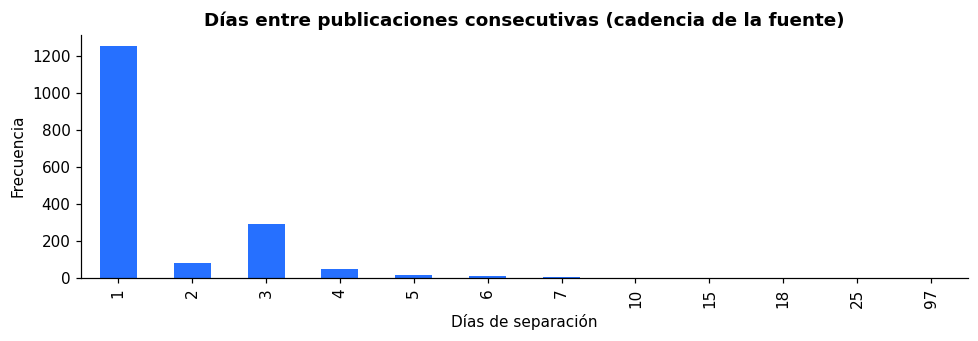

In [8]:
fechas = df['fecha'].sort_values().unique()
delta = np.diff(fechas).astype('timedelta64[D]').astype(int)

print('Distribución de días entre publicaciones:')
ser = pd.Series(delta).value_counts().sort_index()
print(ser.to_string())

huecos = pd.Series(delta).sort_values(ascending=False).head(8)
print('\nHuecos más grandes (días):')
for idx, g in huecos.items():
    print(f'   {fechas[idx].date()} -> {fechas[idx+1].date()} : {g} días')

fig, ax = plt.subplots(figsize=(9, 3.2))
ser.plot.bar(ax=ax, color='#0057ff', alpha=.85)
ax.set_title('Días entre publicaciones consecutivas (cadencia de la fuente)')
ax.set_xlabel('Días de separación'); ax.set_ylabel('Frecuencia')
plt.tight_layout(); plt.show()


## 7. Relación entre variables y redundancia

El front-end muestra en tooltips `Almacenamiento (Mm³)`, `Porcentaje (%)` y `Capacidad NAMO (Mm³)`,
e incluso calcula el **promedio estatal ponderado por `capacidadNamo`**. Verificamos:

* ¿`porcentaje` es reproducible desde `almacenamiento` y `capacidadNamo`?
* ¿Las columnas de capacidad/elevación son **constantes por presa** (candidatas a separarse como metadatos)?


In [9]:
print('=== variedad de valores por columna (estáticas vs dinámicas) ===')
for col in NUM_COLS:
    u = df.groupby('nombre')[col].nunique()
    print(f'  {col:26s} valores distintos por presa -> min {u.min()}, máx {u.max()}')

print('\n=== % de coincidencia entre porcentaje y (alm/NAMO)*100 ===')
calc = pd.to_numeric(df['almacenamientoActualMm3'], errors='coerce') / pd.to_numeric(df['capacidadNamo'], errors='coerce') * 100
giv = pd.to_numeric(df['porcentaje'], errors='coerce')
m = calc.notna() & giv.notna()
print(f'  {100*np.abs(calc[m]-giv[m]).le(0.51).mean():.2f}% de las filas coinciden dentro de ±0.5 pp')

print('\n=== capacidad NAMO vs capacidad de conservación (correlación) ===')
print(pd.concat([pd.to_numeric(df['capacidadNamo'], errors='coerce'), pd.to_numeric(df['capacidadConservacion'], errors='coerce')], axis=1).corr())


=== variedad de valores por columna (estáticas vs dinámicas) ===
  capacidadConservacion      valores distintos por presa -> min 1, máx 2
  elevacionConservacion      valores distintos por presa -> min 1, máx 3
  capacidadNamo              valores distintos por presa -> min 1, máx 32
  elevacionNamo              valores distintos por presa -> min 1, máx 32
  almacenamientoActualMm3    valores distintos por presa -> min 116, máx 1261
  porcentaje                 valores distintos por presa -> min 89, máx 754

=== % de coincidencia entre porcentaje y (alm/NAMO)*100 ===
  99.93% de las filas coinciden dentro de ±0.5 pp

=== capacidad NAMO vs capacidad de conservación (correlación) ===
                       capacidadNamo  capacidadConservacion
capacidadNamo               1.000000               0.989605
capacidadConservacion       0.989605               1.000000


### Interpretación

* Las columnas `capacidadConservacion`, `elevacionConservacion`, `capacidadNamo`, `elevacionNamo`
  **casi no varían por presa** (1 o pocos valores distintos). Son **metadatos estáticos**: repetirlos
  en las ~24 000 filas multiplica innecesariamente el peso del archivo (~5.7 MB) que se descarga
  completo en cada visita. **Separarlos en `presas.json` (nombre → zona, capacidad, elevaciones,
  coordenadas) dejaría `data.json` en la serie temporal compacta.**
* Coincidencia `% ≈ alm/NAMO*100` es >99 %: **se puede omir el campo `porcentaje`** y derivarlo en el
  front-end, o utilizarlo como *check de calidad* al ingestar datos.
* El promedio estatal «ponderado por NAMO» requiere `almacenamiento` y `capacidadNamo`: conviene
  consumirlos también como números (float), no strings.


## 8. Series temporales: evolución del nivel estatal y por presa

Replicamos la lógica del sitio (promedio ponderado por NAMO de las presas principales) para
inspeccionar visualmente la serie e identificar anomalías.


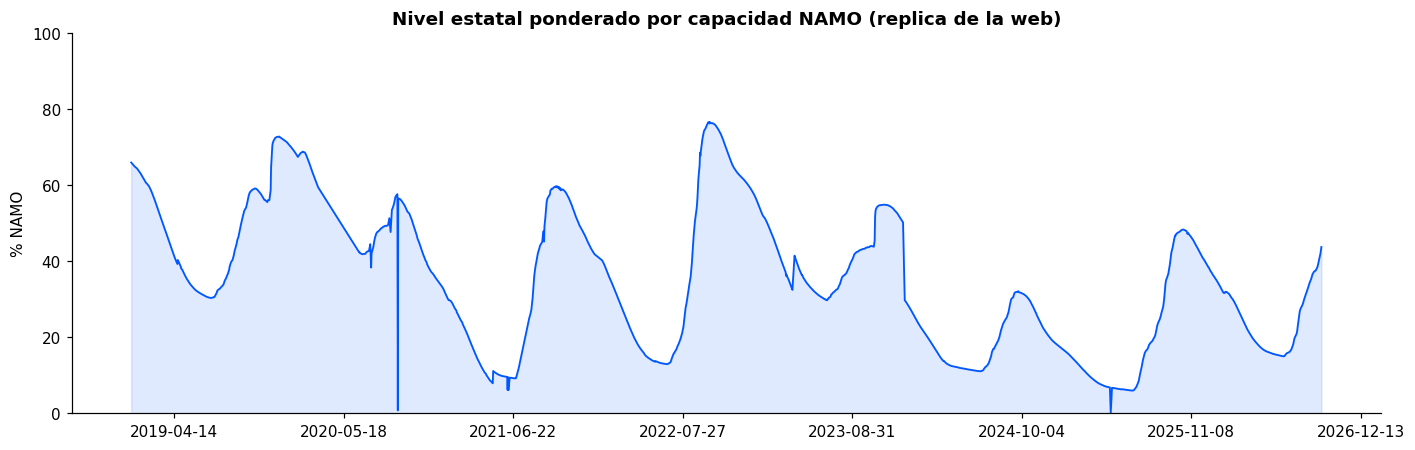

count    1709.0
mean       33.9
std        17.9
min         0.0
25%        17.6
50%        32.1
75%        47.3
max        76.7

Mínimo registrado: 2025-05-02 (0.0 %)
Máximo registrado: 2022-09-29 (76.7 %)


In [10]:
loc_actuales = ['Luis Donaldo Colosio', 'Miguel Hidalgo y Costilla', 'Josefa Ortiz de Domínguez',
                'Gustavo Díaz Ordaz', 'Guillermo Blake Aguilar', 'Eustaquio Buelna',
                'Adolfo López Mateos', 'Sanalona', 'Juan Guerrero Alcocer',
                'José López Portillo', 'Aurelio Benassini V.']

def estado_ponderado(g):
    return (g['alm'].sum() / g['namo'].sum()) * 100

# versión directa sobre df
filt = df[df['nombre'].isin(loc_actuales)].copy()
filt['alm'] = pd.to_numeric(filt['almacenamientoActualMm3'], errors='coerce')
filt['namo'] = pd.to_numeric(filt['capacidadNamo'], errors='coerce')

agg = filt.groupby('fecha').apply(estado_ponderado, include_groups=False).rename('estado_pct')

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(agg.index, agg.values, color='#0057ff', lw=1.2)
ax.fill_between(agg.index, agg.values, color='#0057ff', alpha=.12)
ax.set_ylim(0, 100)
ax.set_title('Nivel estatal ponderado por capacidad NAMO (replica de la web)')
ax.set_ylabel('% NAMO')
ax.xaxis.set_major_locator(mticker.MaxNLocator(10))
plt.tight_layout(); plt.show()

print(agg.describe().round(1).to_string())
print(f'\nMínimo registrado: {agg.idxmin().date()} ({agg.min():.1f} %)')
print(f'Máximo registrado: {agg.idxmax().date()} ({agg.max():.1f} %)')


Escogemos unas presas representativas y graficamos el % de llenado a lo largo del tiempo para
inspeccionar saltos (cambios de nombre, huecos, valores > 100).


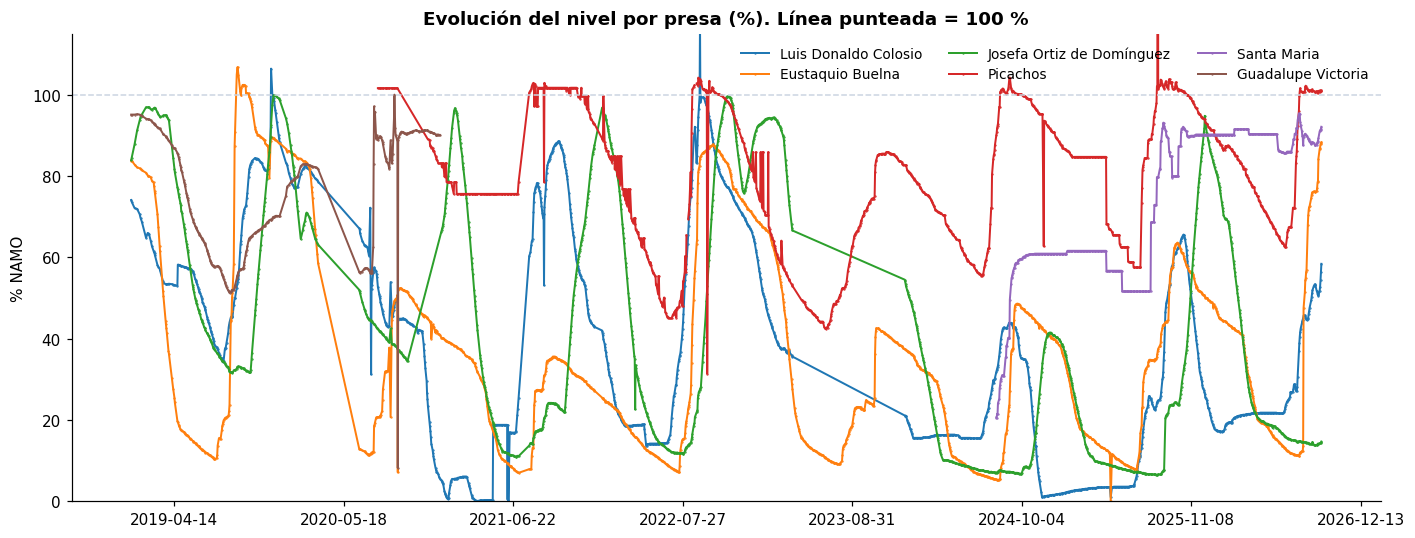

In [11]:
# aplicamos el mapeo canónico para no partir la serie de Josefina
canon = {'Josefa Ortiz de Domínguez': 'Josefa Ortiz de Domínguez',
         'Josefa O. de Dominguez': 'Josefa Ortiz de Domínguez'}
filt2 = df.copy()
filt2['nombre'] = filt2['nombre'].map(lambda n: canon.get(n, n))
filt2['pct'] = pd.to_numeric(filt2['porcentaje'], errors='coerce')

elegidas = ['Luis Donaldo Colosio', 'Eustaquio Buelna', 'Josefa Ortiz de Domínguez',
            'Picachos', 'Santa Maria', 'Guadalupe Victoria']
fig, ax = plt.subplots(figsize=(13, 5))
for n in elegidas:
    s = filt2[filt2['nombre'] == n].sort_values('fecha')
    ax.plot(s['fecha'], s['pct'], label=n, lw=1.3, marker='.', ms=1)
ax.axhline(100, color='#cbd5e1', ls='--', lw=1)
ax.set_ylim(0, 115)
ax.set_ylabel('% NAMO')
ax.set_title('Evolución del nivel por presa (%). Línea punteada = 100 %')
ax.legend(ncol=3, fontsize=9, frameon=False)
ax.xaxis.set_major_locator(mticker.MaxNLocator(10))
plt.tight_layout(); plt.show()


## 9. Distribución de niveles por presa

Útil para decidir umbrales de color (la web hoy divide en ≥80%, 50–80%, 30–50%, <30%).


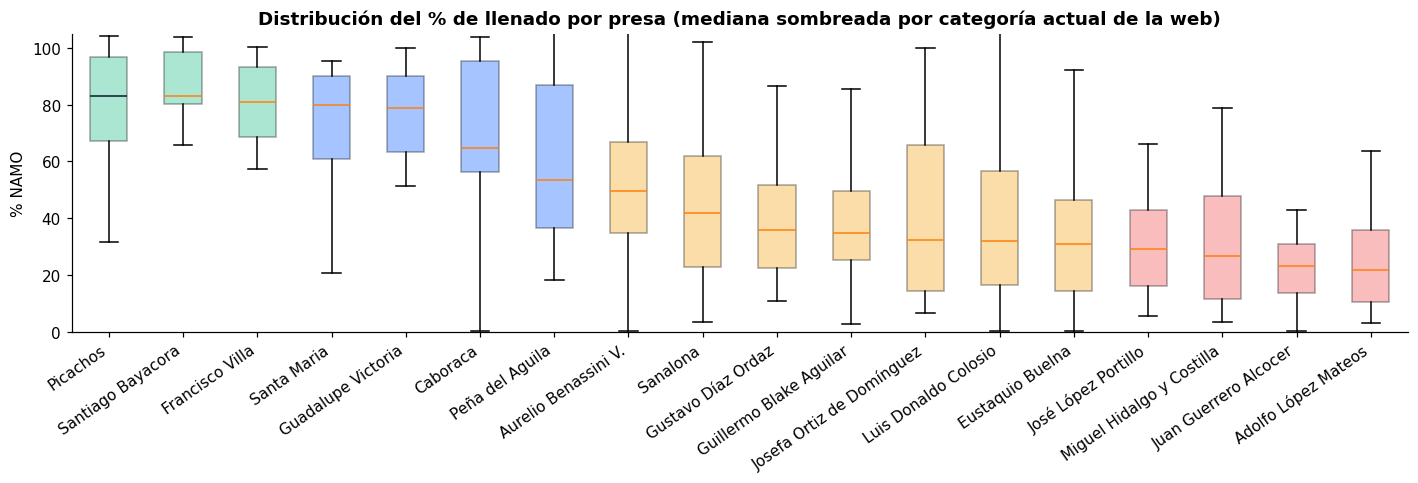

Mediana y rango por presa:
                           mediana_%   mín    máx  % con >80  % con <30
nombre                                                                 
Picachos                        83.1  31.4  325.7       44.4        0.0
Santiago Bayacora               82.9   0.1  103.7       14.9        0.1
Francisco Villa                 81.0   0.1  100.4        9.8        0.1
Santa Maria                     79.7  20.6   95.4       14.8        0.5
Guadalupe Victoria              78.7   8.2  100.0        8.9        0.1
Caboraca                        64.7   0.1  103.8        6.8        0.1
Peña del Aguila                 53.4  18.3  126.2        6.8        1.1
Aurelio Benassini V.            49.4   0.2  110.8       16.7       18.3
Sanalona                        41.9   3.3  102.0       12.9       35.9
Gustavo Díaz Ordaz              35.9  10.7   86.4        1.9       35.3
Guillermo Blake Aguilar         34.6   2.5  103.0        5.4       38.6
Josefa Ortiz de Domínguez       32.2 

In [12]:
piv = filt2.pivot_table(index='fecha', columns='nombre', values='pct')
order = piv.median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 4.5))
bp = ax.boxplot([piv[c].dropna() for c in order], tick_labels=order, vert=True, showfliers=False, patch_artist=True)
pal = ['#10b981', '#0057ff', '#0057ff', '#f59e0b', '#ef4444']
for patch, name in zip(bp['boxes'], order):
    med = piv[name].median()
    color = '#10b981' if med >= 80 else '#0057ff' if med >= 50 else '#f59e0b' if med >= 30 else '#ef4444'
    patch.set_facecolor(color); patch.set_alpha(.35)
bp['medians'][0].set_color('#0f172a')
for lbl in ax.get_xticklabels():
    lbl.set_rotation(35); lbl.set_ha('right')
ax.set_title('Distribución del % de llenado por presa (mediana sombreada por categoría actual de la web)')
ax.set_ylabel('% NAMO'); ax.set_ylim(0, 105)
plt.tight_layout(); plt.show()

print('Mediana y rango por presa:')
summary = piv.median().sort_values(ascending=False).to_frame('mediana_%')
summary['mín'] = piv.min()
summary['máx'] = piv.max()
summary['% con >80'] = piv.apply(lambda c: (c > 80).mean() * 100).round(1)
summary['% con <30'] = piv.apply(lambda c: (c < 30).mean() * 100).round(1)
print(summary.round(1).to_string())


## 10. Conclusiones y plan de mejoras sugerido

Sintetizando los hallazgos del EDA, las mejoras más valiosas para la visualización web son:

### 10.1 Estructura y tipado
1. **Convertir a tipos numéricos reales** (`float`) todas las columnas de medición. Hoy el front-end
   hace `parseFloat()` en cada punto; un JSON con números ahorra trabajo y evita silencios por `"-"`.
2. **Documentar los marcadores no numéricos**: reemplazar `"-"` por `null` (JSON nativo) y manejar en
   Chart.js/Leaflet como «sin dato» (punto/gris) en vez de dejar el valor fuera de rango.
3. **Separar metadatos estáticos de series dinámicas**:
   - `presas.json`: `nombre, alias[], lat, lon, capacidadConservacion, capacidadNamo, elevacion*`.
   - `data.json` (o `series.csv`): `fecha, presa_id, almacenamientoMm3(, porcentaje)`.
   Esto reduciría el peso servido (hoy ~5.7 MB repetidos en ~24 000 filas) y simplifica el mapa.
4. **IDs estables** para presas (`slug`/`id`) en lugar de confiar en nombres con acentos.

### 10.2 Coherencia e integridad
5. **Normalizar nombres** en `aggregate_data.js` con un diccionario canónico y desacentuación
   (Josefa Ortiz de Domínguez = Josefa O. de Dominguez; Peña del Aguila → Peña del Águila).
6. **Validar coherencia interna** al ingestar: `|porcentaje - alm/NAMO*100| ≤ 0.5`. Detectar el
   caso atípico de sep-2020 (porcentaje alto con almacenamiento casi nulo).
7. **Tratar el % > 100**: decidir si se acota a 100 o se marca como «desbordamiento»; sea cual sea,
   `nivelColor()` debe tener categoría para >100 y el mapa no debe mostrar cromatismo indefinido.

### 10.3 Cobertura y series de tiempo
8. **Declarar cobertura de cada presa** (metadatos: `desde`, `hasta`, continuidad) para que el chart
   comparativo anual no mezcle presas de distinta generación y el promedio estatal sea justo.
9. **Promedio estatal**: ponderar siempre por `capacidadNamo` y **excluir días con <k presas**
   (o indicarlo en el título) para no dibujar caídas falsas en 2023.
10. **Huecos temporales**: usar `spanGaps: true` sólo donde el hueco es ≤ umbral y marcar de otro
    color los huecos mayores (mar–jun 2020, jul 2021); nunca interpolar a ciegas.

### 10.4 Cierre
11. Si se busca además performance, **servir por año** (`data_2024.json`, …) o un `series.csv` plano
    + metadatos, y generar el JSON navegable en el build (no en el navegador).


In [13]:
# Bonus: guardar una versión "en formato limpio" (opcional) para inspección rápida
# Descomenta para exportar:
# df_clean = df.copy()
# df_clean['nombre'] = df_clean['nombre'].map(lambda n: canon.get(n, n))
# for c in NUM_COLS:
#     df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')
# df_clean.to_csv('../eda/datos_limpios.csv', index=False)
# df_clean.to_parquet('../eda/datos_limpios.parquet')
print('OK: dataset listo para análisis posteriores.')


OK: dataset listo para análisis posteriores.
